# Beta sweep — R0 vs beta (NGM, cosine seasonality)

Determine initial beta for NM sanity fit.
Cosine seasonality: amp=0.7, peak_day=105 (fixed, not fit).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from kt_epimodel_hira.calibration.simple_model import build_aggregated_inputs
from kt_epimodel_hira.model.parameters import (
    CalibrationParameters, DiseaseParameters, ModelParameters,
)

inputs = build_aggregated_inputs()
pop = inputs["pop_15"].flatten()
N_safe = np.maximum(pop, 1e-10)
matrices = inputs["matrices"]
rho = inputs["rho"].flatten()

dis = DiseaseParameters()  # cosine, amp=0.7, peak=105
gamma = dis.gamma
print(f"Seasonality: {dis.seasonality_mode}, amp={dis.seasonality_amp}, "
      f"peak_day={dis.seasonality_peak_day}")

INITIAL_IMMUNITY = 0.3
s_frac = 1.0 - INITIAL_IMMUNITY

def compute_R0_ngm(beta_uniform, phi=None):
    if phi is None:
        phi = np.ones(15)
    C_h = matrices["C_home"]
    C_s = matrices["C_school"]
    C_w = matrices["C_work"]
    C_o = matrices["C_other"]

    C_eff = np.zeros((15, 15))
    C_eff += beta_uniform * C_h
    C_eff[:4, :4] += beta_uniform * C_s[:4, :4]
    rho_ok = (rho > 0).astype(float)
    for a in range(4, 14):
        C_eff[a, :] += beta_uniform * C_w[a, :] * rho[a] * rho_ok
    C_eff += beta_uniform * C_o

    sf_peak = dis.seasonal_factor(dis.seasonality_peak_day)
    K = (s_frac * sf_peak / gamma) * np.diag(pop) @ np.diag(phi) @ C_eff @ np.diag(1.0 / N_safe)
    eigvals = np.linalg.eigvals(K)
    R0_peak = float(np.max(np.real(eigvals)))

    sf_base = 1.0  # cosine: f(t) = 1 + amp*cos(...), base = 1 + amp*cos(pi) = 1-amp = 0.3
    K_base = (s_frac * sf_base / gamma) * np.diag(pop) @ np.diag(phi) @ C_eff @ np.diag(1.0 / N_safe)
    R0_base = float(np.max(np.real(np.linalg.eigvals(K_base))))

    return R0_peak, R0_base, sf_peak

sf_peak = dis.seasonal_factor(dis.seasonality_peak_day)
print(f"sf(peak={dis.seasonality_peak_day}): {sf_peak:.4f}")
print(f"sf(0): {dis.seasonal_factor(0.0):.4f}")
print(f"sf(182.5): {dis.seasonal_factor(182.5):.4f}  (half year from peak)")


Seasonality: cosine, amp=0.7, peak_day=105.0
sf(peak=105.0): 1.7000
sf(0): 0.8359
sf(182.5): 1.1641  (half year from peak)


In [2]:
# Beta sweep
betas = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.10,
         0.12, 0.15, 0.20, 0.30, 0.50]

print(f"{'beta':>6} | {'R0_peak':>8} | {'R0_base':>8} | outbreak?")
print("-" * 45)
results = []
for b in betas:
    r0p, r0b, sf = compute_R0_ngm(b)
    outbreak = "YES" if r0p > 1.0 else "no"
    print(f"{b:>6.3f} | {r0p:>8.3f} | {r0b:>8.3f} | {outbreak}")
    results.append((b, r0p, r0b))

# Find beta for target R0
from scipy.interpolate import interp1d
betas_arr = np.array([r[0] for r in results])
r0p_arr = np.array([r[1] for r in results])

f_interp = interp1d(r0p_arr, betas_arr, kind="linear", fill_value="extrapolate")
beta_r0_15 = float(f_interp(1.5))
beta_r0_18 = float(f_interp(1.8))
print(f"\nR0_peak = 1.5 => beta ~ {beta_r0_15:.4f}")
print(f"R0_peak = 1.8 => beta ~ {beta_r0_18:.4f}")

# Verify
r0_check_15, _, _ = compute_R0_ngm(beta_r0_15)
r0_check_18, _, _ = compute_R0_ngm(beta_r0_18)
print(f"  verify: beta={beta_r0_15:.4f} => R0={r0_check_15:.3f}")
print(f"  verify: beta={beta_r0_18:.4f} => R0={r0_check_18:.3f}")


  beta |  R0_peak |  R0_base | outbreak?
---------------------------------------------
 0.010 |    0.299 |    0.176 | no
 0.020 |    0.598 |    0.352 | no
 0.030 |    0.897 |    0.527 | no
 0.040 |    1.196 |    0.703 | YES
 0.050 |    1.494 |    0.879 | YES
 0.060 |    1.793 |    1.055 | YES
 0.070 |    2.092 |    1.231 | YES
 0.080 |    2.391 |    1.406 | YES
 0.100 |    2.989 |    1.758 | YES
 0.120 |    3.587 |    2.110 | YES
 0.150 |    4.483 |    2.637 | YES
 0.200 |    5.978 |    3.516 | YES
 0.300 |    8.966 |    5.274 | YES
 0.500 |   14.944 |    8.791 | YES

R0_peak = 1.5 => beta ~ 0.0502
R0_peak = 1.8 => beta ~ 0.0602
  verify: beta=0.0502 => R0=1.500
  verify: beta=0.0602 => R0=1.800


saved ../outputs/calibration/beta_sweep_R0.png


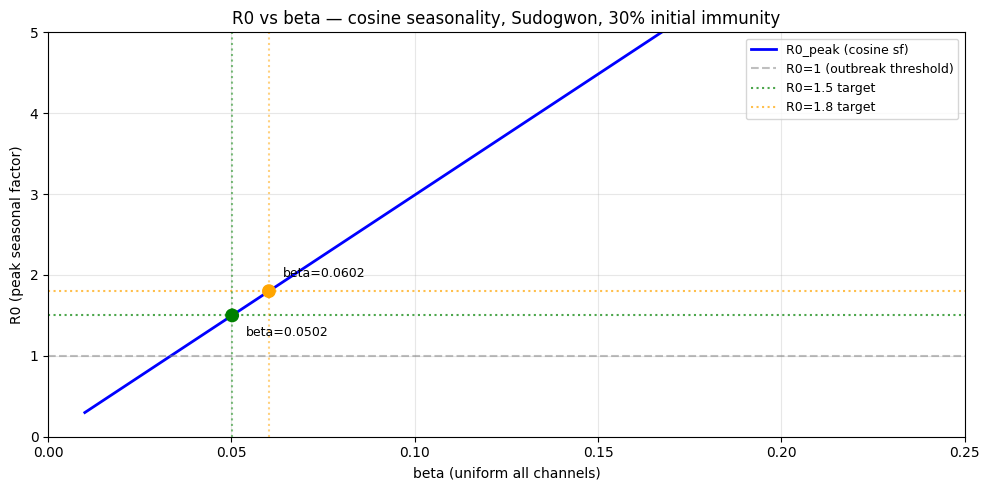


=== Recommendation ===
For v3 sanity NM: beta_init = 0.0502 (R0_peak ~ 1.5)
Safety margin:     beta_init = 0.0602 (R0_peak ~ 1.8)


In [3]:
# Plot
from pathlib import Path
fig, ax = plt.subplots(figsize=(10, 5))
betas_fine = np.linspace(0.01, 0.5, 200)
r0_fine = [compute_R0_ngm(b)[0] for b in betas_fine]

ax.plot(betas_fine, r0_fine, "b-", lw=2, label="R0_peak (cosine sf)")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="R0=1 (outbreak threshold)")
ax.axhline(1.5, color="green", linestyle=":", alpha=0.7, label="R0=1.5 target")
ax.axhline(1.8, color="orange", linestyle=":", alpha=0.7, label="R0=1.8 target")
ax.axvline(beta_r0_15, color="green", linestyle=":", alpha=0.5)
ax.axvline(beta_r0_18, color="orange", linestyle=":", alpha=0.5)
ax.scatter([beta_r0_15, beta_r0_18], [1.5, 1.8], color=["green", "orange"],
           zorder=5, s=80)
ax.annotate(f"beta={beta_r0_15:.4f}", (beta_r0_15, 1.5),
            textcoords="offset points", xytext=(10, -15), fontsize=9)
ax.annotate(f"beta={beta_r0_18:.4f}", (beta_r0_18, 1.8),
            textcoords="offset points", xytext=(10, 10), fontsize=9)
ax.set_xlabel("beta (uniform all channels)")
ax.set_ylabel("R0 (peak seasonal factor)")
ax.set_title("R0 vs beta — cosine seasonality, Sudogwon, 30% initial immunity")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(0, 0.25)
ax.set_ylim(0, 5)
fig.tight_layout()
OUTDIR = Path("../outputs/calibration")
OUTDIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTDIR / "beta_sweep_R0.png", dpi=150, bbox_inches="tight")
print(f"saved {OUTDIR / 'beta_sweep_R0.png'}")
plt.show()

print(f"\n=== Recommendation ===")
print(f"For v3 sanity NM: beta_init = {beta_r0_15:.4f} (R0_peak ~ 1.5)")
print(f"Safety margin:     beta_init = {beta_r0_18:.4f} (R0_peak ~ 1.8)")
